In [1]:
%run /home/mrixen/Case_studies/Clean_code/functions/functions.ipynb

### Getting data

In [2]:
base_path = "/highres_nobackup/mrixen/simulations/Blocking"

# === Define resolutions and folder names ===
resolutions = {
    "R02B06": "R02B06/Ensembles",
    "R02B07": "R02B07/Ensembles",
    "R02B08": "R02B08/Ensembles",
    "R02B08_no_conv": "R02B08_no_conv/Ensembles",
    "R02B09": "R02B09/Ensembles",
    "R02B10": "R02B10/Ensembles"
}

# === Container for all datasets ===
ds_dict_surf = {}

# === Loop through resolutions ===
for res, subdir in resolutions.items():
    path = f"{base_path}/{subdir}"

    # 1️⃣ Find all matching ensemble files
    files = sorted(glob.glob(f"{path}/Blocking_ensemble_{res}_IC_???_out1_concat_ERA_137.nc"))
    if not files:
        print(f"⚠️ No files found for {res}")
        continue

    # 2️⃣ Extract ensemble IDs
    ensemble_ids = [int(re.search(r'_IC_(\d+)_', f).group(1)) for f in files]

    # 3️⃣ Open lazily and in parallel
    print(f"📂 Opening {len(files)} files for {res} ...")
    ds = xr.open_mfdataset(
        files,
        concat_dim="ensemble",
        combine="nested",
        parallel=True,
        engine="netcdf4",
        chunks={"time": 50}
    )

    # 4️⃣ Assign ensemble coordinate
    ds = ds.assign_coords(ensemble=("ensemble", ensemble_ids))

    # 5️⃣ Store dataset in dictionary
    ds_dict_surf[res] = ds
    print(f"✅ Loaded {res} with shape {dict(ds.dims)}")

# === Example access ===
ds_R02B06 = ds_dict_surf["R02B06"]
ds_R02B07_surf = ds_dict_surf["R02B07"]
ds_R02B08_surf = ds_dict_surf["R02B08"]
ds_R02B08_no_conv_surf = ds_dict_surf["R02B08_no_conv"]
ds_R02B09 = ds_dict_surf["R02B09"]
ds_R02B10 = ds_dict_surf["R02B10"]

📂 Opening 50 files for R02B06 ...
✅ Loaded R02B06 with shape {'ensemble': 50, 'time': 169, 'lat': 361, 'lon': 720}
📂 Opening 50 files for R02B07 ...
✅ Loaded R02B07 with shape {'ensemble': 50, 'time': 193, 'lat': 361, 'lon': 720}
📂 Opening 20 files for R02B08 ...
✅ Loaded R02B08 with shape {'ensemble': 20, 'time': 169, 'lat': 361, 'lon': 720}
📂 Opening 20 files for R02B08_no_conv ...
✅ Loaded R02B08_no_conv with shape {'ensemble': 20, 'time': 169, 'lat': 361, 'lon': 720}
📂 Opening 11 files for R02B09 ...
✅ Loaded R02B09 with shape {'ensemble': 11, 'time': 169, 'lat': 361, 'lon': 720}
📂 Opening 3 files for R02B10 ...
✅ Loaded R02B10 with shape {'ensemble': 3, 'time': 169, 'lat': 361, 'lon': 720}


In [3]:
base_path = "/highres_nobackup/mrixen/simulations/Blocking"

# === Define resolutions and folder names ===
resolutions = {
    "R02B06": "R02B06/Ensembles",
    "R02B07": "R02B07/Ensembles",
    "R02B08": "R02B08/Ensembles",
    "R02B08_no_conv": "R02B08_no_conv/Ensembles",
    "R02B09": "R02B09/Ensembles",
    "R02B10": "R02B10/Ensembles"
}

# === Container for all datasets ===
ds_dict = {}

# === Loop through resolutions ===
for res, subdir in resolutions.items():
    path = f"{base_path}/{subdir}"

    # 1️⃣ Find all matching ensemble files
    files = sorted(glob.glob(f"{path}/Blocking_ensemble_{res}_IC_???_out6_concat_ERA_137.nc"))
    if not files:
        print(f"⚠️ No files found for {res}")
        continue

    # 2️⃣ Extract ensemble IDs
    ensemble_ids = [int(re.search(r'_IC_(\d+)_', f).group(1)) for f in files]

    # 3️⃣ Open lazily and in parallel
    print(f"📂 Opening {len(files)} files for {res} ...")
    ds = xr.open_mfdataset(
        files,
        concat_dim="ensemble",
        combine="nested",
        parallel=True,
        engine="netcdf4",
        chunks={"time": 50}
    )

    # 4️⃣ Assign ensemble coordinate
    ds = ds.assign_coords(ensemble=("ensemble", ensemble_ids))

    # 5️⃣ Store dataset in dictionary
    ds_dict[res] = ds
    print(f"✅ Loaded {res} with shape {dict(ds.dims)}")

# === Example access ===
ds_R02B06 = ds_dict["R02B06"]
ds_R02B07 = ds_dict["R02B07"]
ds_R02B08 = ds_dict["R02B08"]
ds_R02B08_no_conv = ds_dict["R02B08_no_conv"]
ds_R02B09 = ds_dict["R02B09"]
ds_R02B10 = ds_dict["R02B10"]

📂 Opening 50 files for R02B06 ...
✅ Loaded R02B06 with shape {'ensemble': 50, 'time': 57, 'plev': 37, 'lat': 361, 'lon': 720}
📂 Opening 50 files for R02B07 ...
✅ Loaded R02B07 with shape {'ensemble': 50, 'time': 65, 'plev': 37, 'lat': 361, 'lon': 720}
📂 Opening 20 files for R02B08 ...
✅ Loaded R02B08 with shape {'ensemble': 20, 'time': 57, 'plev': 37, 'lat': 361, 'lon': 720}
📂 Opening 20 files for R02B08_no_conv ...
✅ Loaded R02B08_no_conv with shape {'ensemble': 20, 'time': 57, 'plev': 37, 'lat': 361, 'lon': 720}
📂 Opening 11 files for R02B09 ...
✅ Loaded R02B09 with shape {'ensemble': 11, 'time': 57, 'plev': 37, 'lat': 361, 'lon': 720}
📂 Opening 3 files for R02B10 ...
✅ Loaded R02B10 with shape {'ensemble': 3, 'time': 57, 'plev': 37, 'lat': 361, 'lon': 720}


In [4]:
start_era = '2023-08-30T00'
end_era = '2023-09-10T00'
ds_era_geo = load_era5_dataset_series_dask(
    start=start_era,
    end=end_era,
    base_path='/net/thermo/atmosdyn/era5/cdf',
    file_prefix='H',
)
ds_era_surf= load_era5_dataset_series_dask(
    start=start_era,
    end=end_era,
    base_path='/net/thermo/atmosdyn/era5/cdf',
    file_prefix='N',
)
ds_era_Z= load_era5_dataset_series_dask(
    start=start_era,
    end=end_era,
    base_path='/net/thermo/atmosdyn/era5/cdf',
    file_prefix='Z',
)
ds_era_surf = ds_era_surf.rename({"MSL": "pres_msl"})

In [5]:
colors = { "R02B06": "purple", "R02B07": "darkorange", "R02B08": "forestgreen", "R02B08_no_conv": "#8da0cb", "R02B09": "mediumblue", "R02B10": "firebrick" }
labels = {"R02B06": "40 km","R02B07": "20 km","R02B08": "10 km","R02B08_no_conv": "10 km conv. off","R02B09": "5 km","R02B10": "2.5 km"}

## Cyclone tracking

In [6]:
initial_time = "2023-08-30T00:00"
initial_lat = 29.0
initial_lon = -67.0
search_radius_deg = 2

In [7]:
track_dict = {}

for res, ds_icon in {
    "R02B06": ds_dict_surf["R02B06"],
    "R02B07": ds_dict_surf["R02B07"],
    "R02B08": ds_dict_surf["R02B08"],
    "R02B08_no_conv": ds_dict_surf["R02B08_no_conv"],
    "R02B09": ds_dict_surf["R02B09"],
    "R02B10": ds_dict_surf["R02B10"]
}.items():

    tracks = []
    for ens in ds_icon.ensemble.values:
        print(ens)
        df = track_cyclone_fast(
            ds_icon.sel(ensemble=ens),
            initial_time=initial_time,
            initial_lat=initial_lat,
            initial_lon=initial_lon,
            search_radius_deg=search_radius_deg
        )
        df["ensemble"] = int(ens)
        tracks.append(df)

    track_dict[res] = pd.concat(tracks, ignore_index=True)

1


KeyboardInterrupt: 

In [ ]:
save_path = "../data/Blocking_cyclone_track_dict.pkl"

with open(save_path, "wb") as f:
    pickle.dump(track_dict, f)

In [7]:
ifs_ensemble_slp = xr.open_dataset('/highres_nobackup/mrixen/simulations/Blocking/IFS_data/IFS_ensemble_mslp.nc')
ifs_ensemble_slp = ifs_ensemble_slp.rename({'latitude': 'lat', 'longitude': 'lon'})
ifs_ensemble_slp = ifs_ensemble_slp.sel(lat=ifs_ensemble_slp.lat[::-1])

In [8]:
#ifs_ensemble_slp = ifs_ensemble_slp.sel(number=slice(1,5))

In [11]:
tracks_ifs  = []
initial_time = "2023-08-30T00:00"
initial_lat = 29.0
initial_lon = -67.0
search_radius_deg = 2

for ens in ifs_ensemble_slp.number.values:
    print(ens)
    df = track_cyclone_ifs(
        ifs_ensemble_slp.sel(number=ens),
        initial_time=initial_time,
        initial_lat=initial_lat,
        initial_lon=initial_lon,
        search_radius_deg=search_radius_deg
    )
    df["ensemble"] = int(ens)
    tracks_ifs.append(df)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50


## Plots

In [12]:
initial_time = "2023-08-30T00:00"
initial_lat = 29.0
initial_lon = -67.0
search_radius_deg = 2

track_dict_era = track_cyclone_era(
            ds_era_surf,
            initial_time=initial_time,
            initial_lat=initial_lat,
            initial_lon=initial_lon,
            search_radius_deg=search_radius_deg
        )

In [13]:
with open("../data/Blocking_cyclone_track_dict.pkl", "rb") as f:
    track_dict = pickle.load(f)
with open("../data/Blocking_acc_df_dict.pkl", "rb") as f:
    acc_df_dict = pickle.load(f)
acc_r02b06 = acc_df_dict["R02B06"]
acc_r02b07 = acc_df_dict["R02B07"]
acc_r02b08 = acc_df_dict["R02B08"]
acc_r02b08_no_conv = acc_df_dict["R02B08_no_conv"]
acc_r02b09 = acc_df_dict["R02B09"]
acc_r02b10 = acc_df_dict["R02B10"]

In [14]:
from scipy.interpolate import interp1d
from sklearn.cluster import KMeans

target_time = pd.Timestamp("2023-09-04T00:00")
n_steps = 30  # common temporal resolution

traj_vectors = []
traj_meta = []  # keep res + ensemble info


In [15]:
traj_vectors = []
traj_meta = []

for res, df in track_dict.items():

    df = df.copy()
    df["time"] = pd.to_datetime(df["time"])

    for ens, df_ens in df.groupby("ensemble"):

        df_sel = df_ens[df_ens["time"] <= target_time]
        if len(df_sel) < 5:
            continue

        # Time-normalized axis [0,1]
        t = np.linspace(0, 1, len(df_sel))
        t_new = np.linspace(0, 1, n_steps)

        # Interpolate trajectory
        f_lon = interp1d(t, df_sel["lon"].values, kind="linear")
        f_lat = interp1d(t, df_sel["lat"].values, kind="linear")

        lon_i = f_lon(t_new)
        lat_i = f_lat(t_new)

        # Remove absolute position (focus on shape)
        lon_i -= lon_i[0]
        lat_i -= lat_i[0]

        # Flatten
        traj_vec = np.concatenate([lon_i, lat_i])

        traj_vectors.append(traj_vec)
        traj_meta.append({
            "res": res,
            "ensemble": ens
        })
traj_meta = pd.DataFrame(traj_meta)

X = np.vstack(traj_vectors)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=50)
labels = kmeans.fit_predict(X)

traj_meta = pd.DataFrame(traj_meta)
traj_meta["cluster"] = labels

In [16]:
clusters = {
    0: traj_meta[traj_meta["cluster"] == 0],
    1: traj_meta[traj_meta["cluster"] == 1],
    2: traj_meta[traj_meta["cluster"] == 2],
}

In [17]:
cluster_labels = {
    0: "Strong poleward",
    1: "Quasi-stationary",
    2: "Moderate NE",
}

cluster_colors = {
    0: "firebrick",
    1: "darkorange",
    2: "darkblue",
}

In [18]:
wspd_p99 = {}

for res, ds in ds_dict.items():

    ds_sel = ds.sel(
        plev=25000,
        lon=slice(-60, -10),
        lat=slice(30, 70),
    )

    wspd = np.sqrt(ds_sel["u"]**2 + ds_sel["v"]**2)

    wspd_p99[res] = wspd.quantile(
        0.99,
        dim=("lat", "lon"),
        skipna=True,
    )

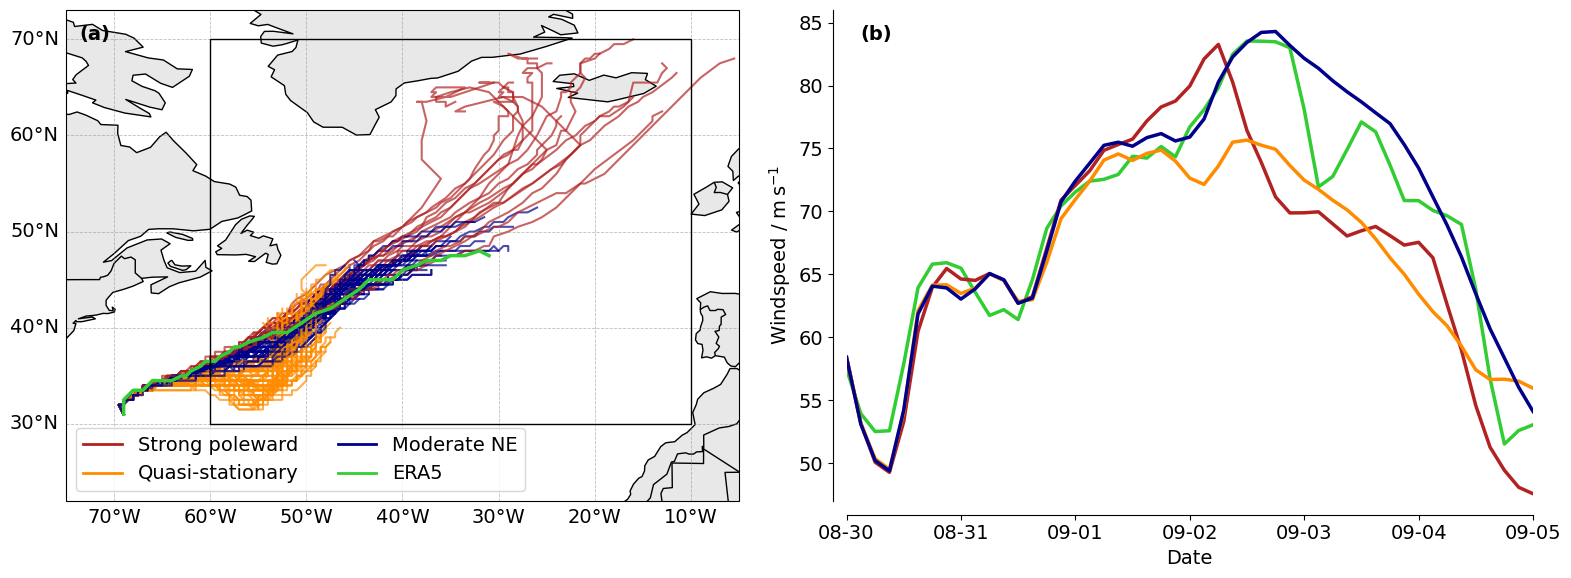

In [19]:
from matplotlib.patches import Rectangle
# ------------------------------------------------------
# Figure setup
# ------------------------------------------------------
fig = plt.figure(figsize=(16, 6), constrained_layout=True)
gs = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[1, 1])

# ======================================================
# LEFT PANEL — Trajectories map
# ======================================================
ax0 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())

ax0.set_extent([-75, -5, 22, 70])
ax0.add_feature(cfeature.COASTLINE)
ax0.add_feature(cfeature.BORDERS)
ax0.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.5)

i = 0
for res, df in track_dict.items():

    df = df.copy()
    df["time"] = pd.to_datetime(df["time"])

    for ens, df_ens in df.groupby("ensemble"):

        df_sel = df_ens[df_ens["time"] <= target_time]
        if len(df_sel) < 5:
            continue

        cluster_val = traj_meta.iloc[i]["cluster"]
        if not np.isfinite(cluster_val):
            i += 1
            continue

        cluster = int(cluster_val)

        ax0.plot(
            df_sel["lon"],
            df_sel["lat"],
            color=cluster_colors[cluster],
            alpha=0.7,
            linewidth=1.5,
            transform=ccrs.PlateCarree(),
        )

        i += 1

# ERA5 track
df_era = track_dict_era.copy()
df_era["time"] = pd.to_datetime(df_era["time"])
df_sel = df_era[df_era["time"] <= target_time]

ax0.plot(
    df_sel["lon"],
    df_sel["lat"],
    color="limegreen",
    linewidth=2.5,
    transform=ccrs.PlateCarree(),
    label="ERA5"
)

legend_handles = [
    plt.Line2D([], [], color=cluster_colors[k], linewidth=2, label=cluster_labels[k])
    for k in sorted(cluster_labels.keys())
]

legend_handles.append(
    plt.Line2D([], [], color="limegreen", linewidth=2, label="ERA5")
)

ax0.legend(handles=legend_handles, frameon=True, loc="lower left", ncol=2)


box = Rectangle(
    (-60, 30),              # lower-left corner (lon, lat)
    50,                     # width  (-10 - (-60))
    40,                     # height (70 - 30)
    linewidth=1,
    edgecolor="black",
    facecolor="none",
    transform=ccrs.PlateCarree(),
    zorder=10
)

ax0.add_patch(box)

# Panel label
ax0.text(0.02, 0.97, "(a)", transform=ax0.transAxes,  fontsize=14, fontweight="bold", va="top", ha="left")

gl = ax0.gridlines(
    draw_labels=True,
    linewidth=0.6,
    color="gray",
    alpha=0.5,
    linestyle="--"
)

gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 14}
gl.ylabel_style = {"size": 14}

# ======================================================
# RIGHT PANEL — Max wind time series
# ======================================================
ax1 = fig.add_subplot(gs[0, 1])

# ERA5
era_box = ds_era_Z.sel(plev=25000, lon=slice(-70, 0), lat=slice(30, 80))
era_wspd = np.sqrt(era_box["U"]**2 + era_box["V"]**2)
era_wspd_p95 = era_wspd.quantile(0.99, dim=("lat", "lon"), skipna=True)

ax1.plot(
    era_wspd_p95.time.values,
    era_wspd_p95.values,
    color="limegreen",
    linewidth=2.5,
    label="ERA5"
)

# Cluster means
for cl in [0, 1, 2]:

    series = []

    for _, row in clusters[cl].iterrows():
        res = row["res"]
        ens = row["ensemble"]

        ws = wspd_p99[res].sel(ensemble=ens)
        series.append(ws)

    mean_ws = xr.concat(series, dim="member").mean("member")

    ax1.plot(
        mean_ws["time"],
        mean_ws,
        color=cluster_colors[cl],
        linewidth=2.5,
        label=cluster_labels[cl]
    )

ax1.set_xlim(pd.to_datetime("2023-08-30"),
             pd.to_datetime("2023-09-05"))
ax1.set_ylim(47, 86)

ax1.set_xlabel("Date")
ax1.set_ylabel(r"Windspeed / $\rm{m\,s^{-1}}$")

ax1.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha="right")

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.spines["left"].set_position(("outward", 10))
ax1.spines["bottom"].set_position(("outward", 10))

# Panel label
ax1.text(0.02, 0.97, "(b)", transform=ax1.transAxes, fontsize=14,
         fontweight="bold", va="top", ha="left")

plt.tight_layout()
plt.savefig("../Figures/Blocking_combined_clustering.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [46]:
counts = (
    traj_meta
    .groupby(["res", "cluster"])
    .size()
    .unstack(fill_value=0)
)

# convert to percentages per resolution
percentages = counts.div(counts.sum(axis=1), axis=0) * 100

# nicer formatting
percentages = percentages.round(1)

percentages = percentages.rename(
    columns={
        0: "Strong poleward",
        1: "Quasi-stationary",
        2: "Moderate NE",
    }
)

percentages

cluster,Strong poleward,Quasi-stationary,Moderate NE
res,,,
R02B06,16.0,42.0,42.0
R02B07,10.0,60.0,30.0
R02B08,5.0,55.0,40.0
R02B08_no_conv,5.0,60.0,35.0
R02B09,9.1,45.5,45.5
R02B10,0.0,33.3,66.7


### IFS clustering

In [29]:
# --- Settings ---
target_time = pd.Timestamp("2023-09-04T00:00")
n_steps = 30  # common temporal resolution
n_clusters = 3

traj_vectors = []
traj_meta_ifs = []

# ------------------------------------------------------
# Loop over IFS tracks
# ------------------------------------------------------
for df in tracks_ifs:  # each df corresponds to one ensemble member
    df = df.copy()
    df["time"] = pd.to_datetime(df["time"])
    
    # Filter up to target_time
    df_sel = df[df["time"] <= target_time]
    if len(df_sel) < 5:  # skip short tracks
        continue

    # Time-normalized axis [0,1]
    t = np.linspace(0, 1, len(df_sel))
    t_new = np.linspace(0, 1, n_steps)

    # Interpolate lon/lat
    f_lon = interp1d(t, df_sel["lon"].values, kind="linear")
    f_lat = interp1d(t, df_sel["lat"].values, kind="linear")

    lon_i = f_lon(t_new)
    lat_i = f_lat(t_new)

    # Remove absolute position to focus on shape
    lon_i -= lon_i[0]
    lat_i -= lat_i[0]

    # Flatten to vector
    traj_vec = np.concatenate([lon_i, lat_i])
    traj_vectors.append(traj_vec)

    # Keep metadata (ensemble number)
    traj_meta_ifs.append({
        "ensemble": int(df_sel["ensemble"].iloc[0])
    })

# ------------------------------------------------------
# Convert to arrays
# ------------------------------------------------------
X = np.vstack(traj_vectors)
traj_meta_ifs = pd.DataFrame(traj_meta_ifs)

# ------------------------------------------------------
# KMeans clustering
# ------------------------------------------------------
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=50)
labels = kmeans.fit_predict(X)

traj_meta_ifs["cluster"] = labels

# Optional: define cluster names and colors
cluster_labels_ifs = {
    0: "Quasi-stationary",
    1: "Moderate NE",
    2: "Strong poleward",
}

cluster_colors_ifs = {
    0: "firebrick",
    1: "darkorange",
    2: "darkblue",
}

traj_meta_ifs["cluster_name"] = traj_meta_ifs["cluster"].map(cluster_labels_ifs)

# ------------------------------------------------------
# Count per cluster
# ------------------------------------------------------
counts_ifs = traj_meta_ifs.groupby("cluster_name").size()
percentages_ifs = (counts_ifs / counts_ifs.sum() * 100).round(1)

print("Cluster counts:\n", counts_ifs)
print("\nCluster percentages:\n", percentages_ifs)

Cluster counts:
 cluster_name
Moderate NE         14
Quasi-stationary    32
Strong poleward      4
dtype: int64

Cluster percentages:
 cluster_name
Moderate NE         28.0
Quasi-stationary    64.0
Strong poleward      8.0
dtype: float64


In [30]:
counts = traj_meta_ifs['cluster'].value_counts().sort_index()
percentages_ifs = (counts / counts.sum() * 100).round(1)

# Wrap into a DataFrame row
percentages_ifs_df = pd.DataFrame([percentages_ifs])
percentages_ifs_df.index = ["IFS"]

# Rename columns to match your cluster labels
percentages_ifs_df = percentages_ifs_df.rename(
    columns={
        0: "Quasi-stationary",
        1: "Moderate NE",
        2: "Strong poleward",
    }
)

In [53]:
percentages_plot = pd.concat([percentages_ifs_df, percentages], axis=0)
percentages_plot

cluster,Quasi-stationary,Moderate NE,Strong poleward
IFS,64.0,28.0,8.0
R02B06,42.0,42.0,16.0
R02B07,60.0,30.0,10.0
R02B08,55.0,40.0,5.0
R02B08_no_conv,60.0,35.0,5.0
R02B09,45.5,45.5,9.1
R02B10,33.3,66.7,0.0


In [50]:
totals_ifs = 50

# ICON totals: sum across clusters for each resolution
totals_icon = counts.sum(axis=1).values  # sums across columns (clusters) per row

# Combine totals: IFS first, then ICON resolutions
totals = [totals_ifs] + list(totals_icon)

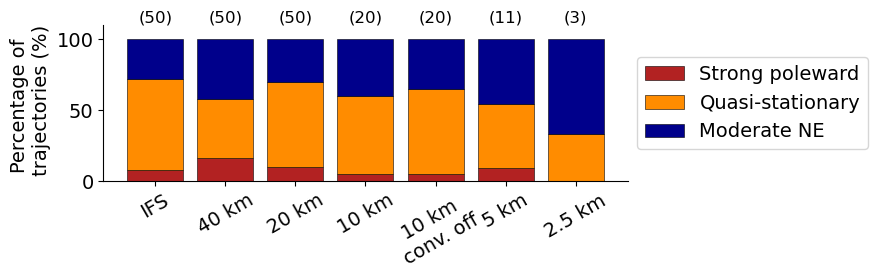

In [52]:
fig, ax = plt.subplots(figsize=(9, 3))  # slightly wider for extra bar

bottom = np.zeros(len(percentages_plot))

cluster_order = ["Strong poleward", "Quasi-stationary", "Moderate NE"]
cluster_colors = {
    "Strong poleward": "firebrick",
    "Quasi-stationary": "darkorange",
    "Moderate NE": "darkblue",
}

for cluster in cluster_order:
    values = percentages_plot[cluster].values

    ax.bar(
        percentages_plot.index,
        values,
        width=0.8,
        bottom=bottom,
        label=cluster,
        edgecolor="black",
        linewidth=0.4,
        color=cluster_colors[cluster],
    )

    bottom += values

# add text above bars
for i, total in enumerate(totals):
    ax.text(
        i,
        110,  # slightly above 100%
        f"({total})",
        ha="center",
        va="bottom",
        fontsize=12
    )

ax.set_ylim(0, 110)
ax.set_ylabel("Percentage of \n trajectories (%)")

# Move legend to the right of the figure
ax.legend(
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    ncols=1
)

# xticks labels (prepend IFS)
xticklabels = ["IFS", "40 km", "20 km", "10 km", "10 km\nconv. off", "5 km", "2.5 km"]
ax.set_xticks(range(len(xticklabels)))
ax.set_xticklabels(xticklabels)
plt.xticks(rotation=30)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("../Figures/Blocking_cluster_percentages.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [54]:
totals

[50,
 np.int64(50),
 np.int64(50),
 np.int64(20),
 np.int64(20),
 np.int64(11),
 np.int64(3)]

In [59]:
cluster_name = "Moderate NE"

# Reconstruct trajectories for each resolution
traj_data = {}
for idx, row in percentages_plot.iterrows():
    total = totals[percentages_plot.index.get_loc(idx)]  # total trajectories for that resolution
    # Number of trajectories in Moderate NE
    n_modNE = int(round(row[cluster_name] / 100 * total))
    # Assign "1" for Moderate NE, "0" for all others
    traj_list = [1]*n_modNE + [0]*(total - n_modNE)
    traj_data[idx] = np.array(traj_list)

# Example check
for res, arr in traj_data.items():
    print(res, "total:", len(arr), "Moderate NE fraction:", np.mean(arr))

IFS total: 50 Moderate NE fraction: 0.28
R02B06 total: 50 Moderate NE fraction: 0.42
R02B07 total: 50 Moderate NE fraction: 0.3
R02B08 total: 20 Moderate NE fraction: 0.4
R02B08_no_conv total: 20 Moderate NE fraction: 0.35
R02B09 total: 11 Moderate NE fraction: 0.45454545454545453
R02B10 total: 3 Moderate NE fraction: 0.6666666666666666


In [72]:
def bootstrap_fraction_diff(traj1, traj2, n_boot=1000, random_state=42):
    """
    Bootstrap test for difference in fractions of Moderate NE between two resolutions.
    Returns:
        obs_diff: observed fraction difference
        ci_lower, ci_upper: 95% confidence interval
    """
    rng = np.random.default_rng(random_state)
    
    # Observed difference
    obs_diff = np.mean(traj1) - np.mean(traj2)
    
    # Bootstrap resampling
    boot_diffs = []
    for _ in range(n_boot):
        sample1 = rng.choice(traj1, size=len(traj1), replace=True)
        sample2 = rng.choice(traj2, size=len(traj2), replace=True)
        boot_diffs.append(np.mean(sample1) - np.mean(sample2))
    
    ci_lower = np.percentile(boot_diffs, 2.5)
    ci_upper = np.percentile(boot_diffs, 97.5)
    
    return obs_diff, ci_lower, ci_upper

In [73]:
resolutions = percentages_plot.index
results = []

for res in resolutions[1:]:  # skip IFS itself
    obs_diff, ci_lower, ci_upper = bootstrap_fraction_diff(traj_data["IFS"], traj_data[res])
    results.append({
        "resolution": res,
        "obs_diff": obs_diff,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "significant": (ci_lower > 0) or (ci_upper < 0)
    })

df_results = pd.DataFrame(results)
print(df_results)

       resolution  obs_diff  ci_lower  ci_upper  significant
0          R02B06 -0.140000  -0.34000  0.040000        False
1          R02B07 -0.020000  -0.20000  0.140500        False
2          R02B08 -0.120000  -0.38025  0.120250        False
3  R02B08_no_conv -0.070000  -0.31025  0.180000        False
4          R02B09 -0.174545  -0.48750  0.138182        False
5          R02B10 -0.386667  -0.80000  0.220500        False
